
# Data loading




In [ ]:
import pandas as pd
df = pd.read_excel('data_final_2.xlsx')
print(df.head())

                                                text main_label      sub_label
0  आजसम्म तिमिहरुले एउटा गतिलो नेपालि फ्लिम बनायन...       hate        blaming
1  काठमाडौँ उपत्यका खानेपानी लिमिटेड (केयुकेएल) म...   non-hate        neutral
2  विकास निर्माणमा लागू होस्। फेसबुक अब कहिले पनि...   non-hate  miscellaneous
3                                     थुग वीएस गोट 🤣       hate        mocking
4  हे इस नोट सिंगर.हे इस जस्ट फन्नी इन्टरटेनर्स व...   non-hate  miscellaneous


# Data Count

In [ ]:
print("Main-label counts:")
print(df['main_label'].value_counts())

Main-label counts:
main_label
hate        11601
non-hate    10912
Name: count, dtype: int64


In [ ]:
print("Sub-label counts:")
print(df['sub_label'].value_counts())

Sub-label counts:
sub_label
mocking          5144
neutral          4723
dehumanizing     3430
miscellaneous    2851
blaming          2249
supportive       2089
informative      2027
Name: count, dtype: int64


In [ ]:
print(f"DataFrame shape before removing 'miscellaneous' sub-label: {df.shape}")
df = df[df['sub_label'] != 'miscellaneous']
print(f"DataFrame shape after removing 'miscellaneous' sub-label: {df.shape}")

DataFrame shape before removing 'miscellaneous' sub-label: (22513, 3)
DataFrame shape after removing 'miscellaneous' sub-label: (19662, 3)


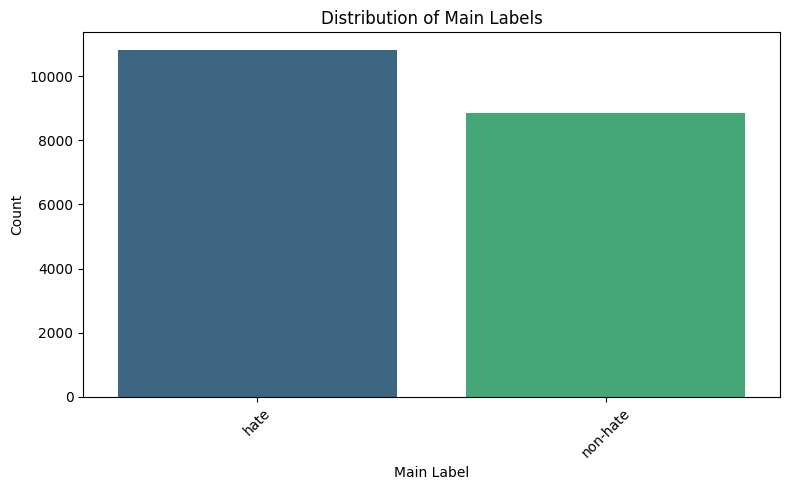

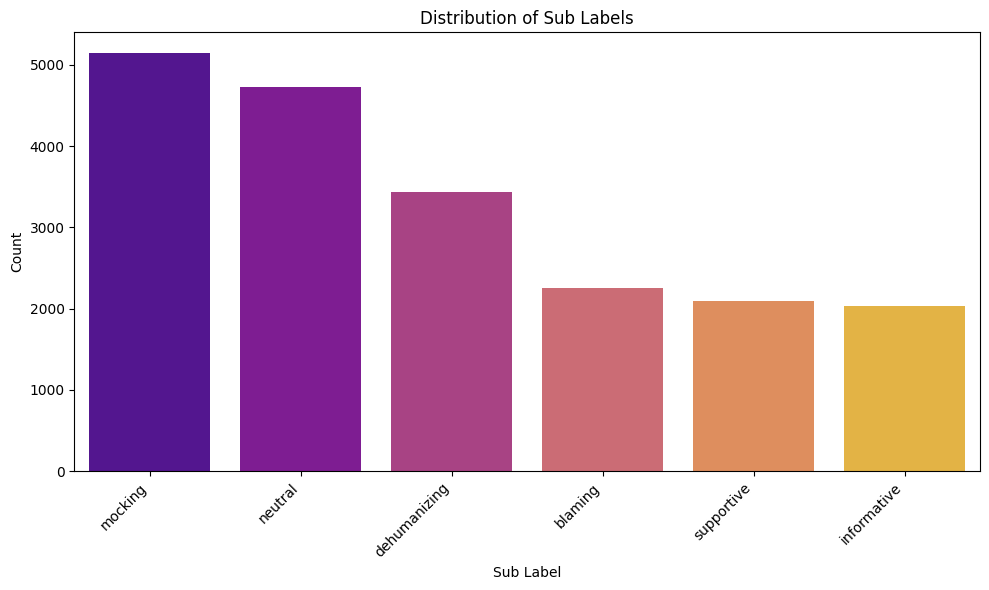

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get counts for main_label
main_label_counts = df['main_label'].value_counts()

# Plotting main_label counts
plt.figure(figsize=(8, 5))
sns.barplot(x=main_label_counts.index, y=main_label_counts.values, palette='viridis', hue=main_label_counts.index, legend=False)
plt.title('Distribution of Main Labels')
plt.xlabel('Main Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Get counts for sub_label
sub_label_counts = df['sub_label'].value_counts()

# Plotting sub_label counts
plt.figure(figsize=(10, 6))
sns.barplot(x=sub_label_counts.index, y=sub_label_counts.values, palette='plasma', hue=sub_label_counts.index, legend=False)
plt.title('Distribution of Sub Labels')
plt.xlabel('Sub Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
!pip install indic-transliteration

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 6.2 MB/s eta 0:00:00


## Text Preprocessing

In [ ]:
import unicodedata
import re
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate

def clean_text_for_ner(text):

    if pd.isna(text):
        return ""

    text = str(text)

    # Normalize Unicode
    text = unicodedata.normalize("NFC", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove emojis
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub('', text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()
    processed_words = []

    for word in words:
        # If word is purely English alphabet → transliterate
        if re.match(r'^[A-Za-z]+$', word):
            try:
                nep_word = transliterate(word, sanscript.ITRANS, sanscript.DEVANAGARI)
                processed_words.append(nep_word)
            except:
                processed_words.append(word)
        else:
            processed_words.append(word)

    return " ".join(processed_words)

df["clean_text"] = df["text"].apply(clean_text_for_ner)

In [ ]:
print(f"Number of duplicate rows before removal: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0


#  Tokenization

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

# Download the 'punkt' tokenizer data if not already downloaded
try:
    nltk.data.find('tokenizers/punkt_tab') # Check for punkt_tab
except LookupError:
    nltk.download('punkt_tab') # Download punkt_tab if not found

df['tokenized_text'] = df['clean_text'].apply(word_tokenize)
print(df[['clean_text', 'tokenized_text']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


                                          clean_text  \
0  आजसम्म तिमिहरुले एउटा गतिलो नेपालि फ्लिम बनायन...   
1  काठमाडौँ उपत्यका खानेपानी लिमिटेड (केयुकेएल) म...   
3                                     थुग वीएस गोट 🤣   
5             तिमीले मनलाग्दी बोलेर जनता नझुकाई देउ।   
7                        नेपाली बाबु सारै ह्यान्डसम।   

                                      tokenized_text  
0  [आजसम्म, तिमिहरुले, एउटा, गतिलो, नेपालि, फ्लिम...  
1  [काठमाडौँ, उपत्यका, खानेपानी, लिमिटेड, (, केयु...  
3                                [थुग, वीएस, गोट, 🤣]  
5      [तिमीले, मनलाग्दी, बोलेर, जनता, नझुकाई, देउ।]  
7                   [नेपाली, बाबु, सारै, ह्यान्डसम।]  


# Stopwords removal

In [ ]:
stopwords_file_path = "/content/grammer stop_words.txt"

# Load the stopwords into a list or set
with open(stopwords_file_path, 'r', encoding='utf-8') as file:
    nepali_stopwords = {line.strip() for line in file}

# Check the stopwords
print(f"Loaded {len(nepali_stopwords)} Nepali stopwords.")
print(nepali_stopwords)

Loaded 75 Nepali stopwords.
{'सट्टा', 'बरु', 'तेस्कारण', 'फेरि', 'भित्र', 'अन्यथा', 'बीच', 'देखि', 'मा', 'त्यसपछि', 'अझै', 'नै', 'त', 'वा', 'भने', 'बीचमा', 'सम्म', 'जब', 'न', 'माथि', 'वास्तवमा', 'तापनी', 'नत्र', 'वरीपरी', 'संगै', 'आदि', 'तर', 'थप', 'अर्थात्', 'यसरी', 'तल', 'फेरी', 'विरुद्ध', 'नि', 'कि', 'तथा', 'त्यहाँ', 'या', 'सोही', 'त्सपछि', 'बारेमा', 'भर', 'जबकि', 'निम्ति', 'लागि', 'सधै', 'साथ', 'पछि', 'पनि', 'बाट', 'बारे', 'मात्र', 'र', 'संग', 'किनभने', 'किन', 'भन्दा', 'यसबाहेक', 'यसैले', 'साथै', 'प्रति', 'बिरुद्ध', 'यसपछि', 'तदनुसार', 'त्सैले', 'द्वारा', 'बाहिर', 'मार्फत', 'यहाँसम्म', 'सायद', 'लाई', 'अर्थात', 'ले', 'बाहेक', 'तिर'}


In [ ]:
def remove_stopwords_nepali(tokens, stopwords):

    filtered_tokens = []

    for token in tokens:
        original_token = token
        token_modified = False

        # Check for full word matches and suffixes
        for stopword in stopwords:
            if token == stopword:  # Remove stopword if it's a full word
                token = ""
                token_modified = True
                break  # No need to check further stopwords if one has been removed

            elif token.endswith(stopword):  # Check if stopword is a suffix
                remaining_token = token[:-len(stopword)].strip()
                if remaining_token:  # Only modify if the remaining token is valid
                    token = remaining_token
                    token_modified = True
                    break  # No need to check further stopwords if one has been removed

        # Add only non-empty tokens and those that are meaningfully modified
        if token and (not token_modified or token != original_token):
            filtered_tokens.append(token)

    return filtered_tokens

df['stop_words'] = df['tokenized_text'].apply(lambda x: remove_stopwords_nepali(x, nepali_stopwords))
display(df.head())

,text,main_label,sub_label,clean_text,tokenized_text,stop_words
0,आजसम्म तिमिहरुले एउटा गतिलो नेपालि फ्लिम बनायन...,hate,blaming,आजसम्म तिमिहरुले एउटा गतिलो नेपालि फ्लिम बनायन...,"[आजसम्म, तिमिहरुले, एउटा, गतिलो, नेपालि, फ्लिम...","[आज, तिमिहरु, एउटा, गतिलो, नेपालि, फ्लिम, बनाय..."
1,काठमाडौँ उपत्यका खानेपानी लिमिटेड (केयुकेएल) म...,non-hate,neutral,काठमाडौँ उपत्यका खानेपानी लिमिटेड (केयुकेएल) म...,"[काठमाडौँ, उपत्यका, खानेपानी, लिमिटेड, (, केयु...","[काठमाडौँ, उपत्यका, खानेपानी, लिमिटेड, (, केयु..."
3,थुग वीएस गोट 🤣,hate,mocking,थुग वीएस गोट 🤣,"[थुग, वीएस, गोट, 🤣]","[थुग, वीएस, गोट, 🤣]"
5,तिमीले मनलाग्दी बोलेर जनता नझुकाई देउ।,hate,blaming,तिमीले मनलाग्दी बोलेर जनता नझुकाई देउ।,"[तिमीले, मनलाग्दी, बोलेर, जनता, नझुकाई, देउ।]","[तिमी, मनलाग्दी, बोले, जनता, नझुकाई, देउ।]"
7,नेपाली बाबु सारै ह्यान्डसम।,non-hate,neutral,नेपाली बाबु सारै ह्यान्डसम।,"[नेपाली, बाबु, सारै, ह्यान्डसम।]","[नेपाली, बाबु, सारै, ह्यान्डसम।]"


# Label Encoder

In [ ]:

from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["main_label"])

print("Classes:", le.classes_)

Classes: ['hate' 'non-hate']


# Train-test split

In [ ]:
from sklearn.model_selection import train_test_split

X = df["stop_words"]
y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for hate speech dataset
)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary Size:", vocab_size)

Vocabulary Size: 31220


# Padding

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 100   # you can tune this

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

# BiLSTM Model for Main-label

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout

model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=128,
              input_length=max_length),

    Bidirectional(LSTM(64)),

    Dropout(0.5),

    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/25
443/443 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.6617 - loss: 0.5894 - val_accuracy: 0.7985 - val_loss: 0.4249
Epoch 2/25
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9037 - loss: 0.2349 - val_accuracy: 0.7908 - val_loss: 0.4827
Epoch 3/25
443/443 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9639 - loss: 0.1012 - val_accuracy: 0.7737 - val_loss: 0.6372
Epoch 4/25
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9805 - loss: 0.0515 - val_accuracy: 0.7750 - val_loss: 0.9265
Epoch 5/25
443/443 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9887 - loss: 0.0325 - val_accuracy: 0.7680 - val_loss: 0.9702
Epoch 6/25
443/443 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9908 - loss: 0.0226 - val_accuracy: 0.7711 - val_loss: 1.0775
Epoch 7/25
443/443 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9942 - loss: 0.0159 - val_accuracy: 0.7635 - val_loss: 1.2448
Epoch 8/25
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9956 - loss: 0.0146 - val_acc

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predict probabilities
y_pred_prob = model.predict(X_test_pad)

# Convert to 0/1
y_pred = (y_pred_prob > 0.5).astype("int32")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Accuracy: 0.7943046020849225

Classification Report:
              precision    recall  f1-score   support

        hate       0.81      0.82      0.81      2165
    non-hate       0.77      0.77      0.77      1768

    accuracy                           0.79      3933
   macro avg       0.79      0.79      0.79      3933
weighted avg       0.79      0.79      0.79      3933


Confusion Matrix:
[[1771  394]
 [ 415 1353]]


In [ ]:
non_hate_df = df[df['main_label'] == 'non-hate']
print(non_hate_df.head())

                                                 text main_label    sub_label  \
1   काठमाडौँ उपत्यका खानेपानी लिमिटेड (केयुकेएल) म...   non-hate      neutral   
7                         नेपाली बाबु सारै ह्यान्डसम।   non-hate      neutral   
10               कतारमा पनि कोभिड १९ को संक्रमण बढ्दो   non-hate  informative   
11                              तपाई को भनाइ मन पर्यो   non-hate   supportive   
14                                             थर्बोउ   non-hate      neutral   

                                           clean_text  \
1   काठमाडौँ उपत्यका खानेपानी लिमिटेड (केयुकेएल) म...   
7                         नेपाली बाबु सारै ह्यान्डसम।   
10               कतारमा पनि कोभिड १९ को संक्रमण बढ्दो   
11                              तपाई को भनाइ मन पर्यो   
14                                             थर्बोउ   

                                       tokenized_text  \
1   [काठमाडौँ, उपत्यका, खानेपानी, लिमिटेड, (, केयु...   
7                    [नेपाली, बाबु, सारै, ह्यान्डसम।]   

In [ ]:
print("Sub-label counts for non-hate entries:")
print(non_hate_df['sub_label'].value_counts())

Sub-label counts for non-hate entries:
sub_label
neutral        4723
supportive     2089
informative    2027
blaming           1
Name: count, dtype: int64


In [ ]:
non_hate_df = non_hate_df[non_hate_df['sub_label'] != 'blaming']
print("Sub-label counts after removing 'blaming' category:")
print(non_hate_df['sub_label'].value_counts())

Sub-label counts after removing 'blaming' category:
sub_label
neutral        4723
supportive     2089
informative    2027
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode sub_label for non-hate entries
le_sub = LabelEncoder()
non_hate_df['sub_label_encoded'] = le_sub.fit_transform(non_hate_df['sub_label'])

print("Sub-label classes and their encoded values:")
for i, label in enumerate(le_sub.classes_):
    print(f"{label}: {i}")


Sub-label classes and their encoded values:
informative: 0
neutral: 1
supportive: 2


In [ ]:
from sklearn.model_selection import train_test_split

X_nh = non_hate_df["stop_words"]
y_nh = non_hate_df["sub_label_encoded"]

X_train_nh, X_test_nh, y_train_nh, y_test_nh = train_test_split(
    X_nh,
    y_nh,
    test_size=0.2,
    random_state=42,
    stratify=y_nh
)

print(f"X_train_nh shape: {X_train_nh.shape}")
print(f"X_test_nh shape: {X_test_nh.shape}")
print(f"y_train_nh shape: {y_train_nh.shape}")
print(f"y_test_nh shape: {y_test_nh.shape}")

X_train_nh shape: (7071,)
X_test_nh shape: (1768,)
y_train_nh shape: (7071,)
y_test_nh shape: (1768,)


# Non-hate Sub-label model

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer_nh = Tokenizer(oov_token="<OOV>")
tokenizer_nh.fit_on_texts(X_train_nh)

X_train_nh_seq = tokenizer_nh.texts_to_sequences(X_train_nh)
X_test_nh_seq = tokenizer_nh.texts_to_sequences(X_test_nh)

vocab_size_nh = len(tokenizer_nh.word_index) + 1
print("Vocabulary Size (non-hate sub-labels):", vocab_size_nh)


Vocabulary Size (non-hate sub-labels): 15081


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length_nh = 100 # Define a max length for padding

X_train_nh_pad = pad_sequences(
    X_train_nh_seq,
    maxlen=max_length_nh,
    padding="post",
    truncating="post"
)

X_test_nh_pad = pad_sequences(
    X_test_nh_seq,
    maxlen=max_length_nh,
    padding="post",
    truncating="post"
)

print("Padded training sequences shape:", X_train_nh_pad.shape)
print("Padded testing sequences shape:", X_test_nh_pad.shape)

Padded training sequences shape: (7071, 100)
Padded testing sequences shape: (1768, 100)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout

num_classes_nh = len(le_sub.classes_) # Get the number of unique sub-labels

model_nh = Sequential([
    Embedding(input_dim=vocab_size_nh,
              output_dim=128,
              input_length=max_length_nh),

    Bidirectional(LSTM(64)),

    Dropout(0.5),

    Dense(64, activation="relu"),
    Dense(num_classes_nh, activation="softmax") # Output layer for multi-class classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout

num_classes_nh = len(le_sub.classes_) # Get the number of unique sub-labels

model_nh = Sequential([
    Embedding(input_dim=vocab_size_nh,
              output_dim=128),

    Bidirectional(LSTM(64)),

    Dropout(0.5),

    Dense(64, activation="relu"),
    Dense(num_classes_nh, activation="softmax") # Output layer for multi-class classification
])

In [ ]:
model_nh.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_nh = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_nh = model_nh.fit(
    X_train_nh_pad,
    y_train_nh,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_nh]
)

Epoch 1/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5653 - loss: 0.9485 - val_accuracy: 0.7797 - val_loss: 0.5752
Epoch 2/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8831 - loss: 0.3272 - val_accuracy: 0.7825 - val_loss: 0.6216
Epoch 3/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9740 - loss: 0.0890 - val_accuracy: 0.7754 - val_loss: 0.8376
Epoch 4/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9917 - loss: 0.0256 - val_accuracy: 0.7782 - val_loss: 0.9973
Epoch 5/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9945 - loss: 0.0195 - val_accuracy: 0.7740 - val_loss: 1.1582
Epoch 6/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9964 - loss: 0.0153 - val_accuracy: 0.7613 - val_loss: 1.3477
Epoch 7/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9988 - loss: 0.0068 - val_accuracy: 0.7740 - val_loss: 1.2622
Epoch 8/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9990 - loss: 0.0047 - val_accu

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Predict probabilities for multi-class
y_pred_prob_nh = model_nh.predict(X_test_nh_pad)

# Convert probabilities to class labels (index of the max probability)
y_pred_nh = np.argmax(y_pred_prob_nh, axis=1)

# Accuracy
accuracy_nh = accuracy_score(y_test_nh, y_pred_nh)
print("Accuracy (non-hate sub-labels):", accuracy_nh)

# Classification Report
print("\nClassification Report (non-hate sub-labels):")
print(classification_report(y_test_nh, y_pred_nh, target_names=le_sub.classes_))

# Confusion Matrix
print("\nConfusion Matrix (non-hate sub-labels):")
print(confusion_matrix(y_test_nh, y_pred_nh))

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Accuracy (non-hate sub-labels): 0.7765837104072398

Classification Report (non-hate sub-labels):
              precision    recall  f1-score   support

 informative       0.70      0.57      0.63       405
     neutral       0.76      0.90      0.82       945
  supportive       0.93      0.69      0.79       418

    accuracy                           0.78      1768
   macro avg       0.80      0.72      0.75      1768
weighted avg       0.79      0.78      0.77      1768


Confusion Matrix (non-hate sub-labels):
[[231 168   6]
 [ 76 854  15]
 [ 23 107 288]]


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate class weights for y_train_nh
class_weights_nh = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_nh),
    y=y_train_nh
)

# Convert class weights to a dictionary mapping class index to weight
class_weights_dict_nh = dict(enumerate(class_weights_nh))

print("Calculated Class Weights (non-hate sub-labels):")
for class_idx, weight in class_weights_dict_nh.items():
    print(f"Class {class_idx} ({le_sub.inverse_transform([class_idx])[0]}): {weight:.2f}")

Calculated Class Weights (non-hate sub-labels):
Class 0 (informative): 1.45
Class 1 (neutral): 0.62
Class 2 (supportive): 1.41


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_nh = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_nh = model_nh.fit(
    X_train_nh_pad,
    y_train_nh,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_nh],
    class_weight=class_weights_dict_nh # Apply class weights here
)

Epoch 1/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8590 - loss: 0.3908 - val_accuracy: 0.7726 - val_loss: 0.6182
Epoch 2/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9720 - loss: 0.0914 - val_accuracy: 0.7698 - val_loss: 0.8473
Epoch 3/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9915 - loss: 0.0263 - val_accuracy: 0.7754 - val_loss: 0.9462
Epoch 4/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9953 - loss: 0.0164 - val_accuracy: 0.7387 - val_loss: 1.1685
Epoch 5/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9965 - loss: 0.0101 - val_accuracy: 0.7641 - val_loss: 1.4102
Epoch 6/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9976 - loss: 0.0066 - val_accuracy: 0.7119 - val_loss: 1.4842
Epoch 7/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9989 - loss: 0.0026 - val_accuracy: 0.7627 - val_loss: 1.5634
Epoch 8/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 1.0000 - loss: 7.6380e-04 - val_

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Predict probabilities for multi-class
y_pred_prob_nh_weighted = model_nh.predict(X_test_nh_pad)

# Convert probabilities to class labels (index of the max probability)
y_pred_nh_weighted = np.argmax(y_pred_prob_nh_weighted, axis=1)

# Accuracy
accuracy_nh_weighted = accuracy_score(y_test_nh, y_pred_nh_weighted)
print("Accuracy (non-hate sub-labels with class weights):", accuracy_nh_weighted)

# Classification Report
print("\nClassification Report (non-hate sub-labels with class weights):")
print(classification_report(y_test_nh, y_pred_nh_weighted, target_names=le_sub.classes_))

# Confusion Matrix
print("\nConfusion Matrix (non-hate sub-labels with class weights):")
print(confusion_matrix(y_test_nh, y_pred_nh_weighted))

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy (non-hate sub-labels with class weights): 0.7703619909502263

Classification Report (non-hate sub-labels with class weights):
              precision    recall  f1-score   support

 informative       0.62      0.70      0.66       405
     neutral       0.84      0.79      0.82       945
  supportive       0.78      0.79      0.79       418

    accuracy                           0.77      1768
   macro avg       0.75      0.76      0.75      1768
weighted avg       0.78      0.77      0.77      1768


Confusion Matrix (non-hate sub-labels with class weights):
[[282  94  29]
 [132 751  62]
 [ 38  51 329]]


# Hate Sub-label model

In [ ]:
hate_df = df[df['main_label'] == 'hate']
print(hate_df.head())

                                                text main_label     sub_label  \
0  आजसम्म तिमिहरुले एउटा गतिलो नेपालि फ्लिम बनायन...       hate       blaming   
3                                     थुग वीएस गोट 🤣       hate       mocking   
5             तिमीले मनलाग्दी बोलेर जनता नझुकाई देउ।       hate       blaming   
8                             मुगी आईबी को नाम ना ले       hate  dehumanizing   
9  आशा नै मरि सक्यो अब त। अहिले सम्म त मरेको भए न...       hate       mocking   

                                          clean_text  \
0  आजसम्म तिमिहरुले एउटा गतिलो नेपालि फ्लिम बनायन...   
3                                     थुग वीएस गोट 🤣   
5             तिमीले मनलाग्दी बोलेर जनता नझुकाई देउ।   
8                             मुगी आईबी को नाम ना ले   
9  आशा नै मरि सक्यो अब त। अहिले सम्म त मरेको भए न...   

                                      tokenized_text  \
0  [आजसम्म, तिमिहरुले, एउटा, गतिलो, नेपालि, फ्लिम...   
3                                [थुग, वीएस, गोट, 🤣]   
5      [

In [ ]:
print("Sub-label counts for hate entries:")
print(hate_df['sub_label'].value_counts())

Sub-label counts for hate entries:
sub_label
mocking         5144
dehumanizing    3430
blaming         2248
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode sub_label for hate entries
le_sub_hate = LabelEncoder()
hate_df['sub_label_encoded'] = le_sub_hate.fit_transform(hate_df['sub_label'])

print("Sub-label classes and their encoded values (hate entries):")
for i, label in enumerate(le_sub_hate.classes_):
    print(f"{label}: {i}")

Sub-label classes and their encoded values (hate entries):
blaming: 0
dehumanizing: 1
mocking: 2


/tmp/ipykernel_434/2001368687.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hate_df['sub_label_encoded'] = le_sub_hate.fit_transform(hate_df['sub_label'])


In [ ]:
hate_df = df[df['main_label'] == 'hate'].copy()
print(hate_df.head())

                                                text main_label     sub_label  \
0  आजसम्म तिमिहरुले एउटा गतिलो नेपालि फ्लिम बनायन...       hate       blaming   
3                                     थुग वीएस गोट 🤣       hate       mocking   
5             तिमीले मनलाग्दी बोलेर जनता नझुकाई देउ।       hate       blaming   
8                             मुगी आईबी को नाम ना ले       hate  dehumanizing   
9  आशा नै मरि सक्यो अब त। अहिले सम्म त मरेको भए न...       hate       mocking   

                                          clean_text  \
0  आजसम्म तिमिहरुले एउटा गतिलो नेपालि फ्लिम बनायन...   
3                                     थुग वीएस गोट 🤣   
5             तिमीले मनलाग्दी बोलेर जनता नझुकाई देउ।   
8                             मुगी आईबी को नाम ना ले   
9  आशा नै मरि सक्यो अब त। अहिले सम्म त मरेको भए न...   

                                      tokenized_text  \
0  [आजसम्म, तिमिहरुले, एउटा, गतिलो, नेपालि, फ्लिम...   
3                                [थुग, वीएस, गोट, 🤣]   
5      [

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode sub_label for hate entries
le_sub_hate = LabelEncoder()
hate_df['sub_label_encoded'] = le_sub_hate.fit_transform(hate_df['sub_label'])

print("Sub-label classes and their encoded values (hate entries):")
for i, label in enumerate(le_sub_hate.classes_):
    print(f"{label}: {i}")

Sub-label classes and their encoded values (hate entries):
blaming: 0
dehumanizing: 1
mocking: 2


In [ ]:
from sklearn.model_selection import train_test_split

X_hate = hate_df["stop_words"]
y_hate = hate_df["sub_label_encoded"]

X_train_hate, X_test_hate, y_train_hate, y_test_hate = train_test_split(
    X_hate,
    y_hate,
    test_size=0.2,
    random_state=42,
    stratify=y_hate
)

print(f"X_train_hate shape: {X_train_hate.shape}")
print(f"X_test_hate shape: {X_test_hate.shape}")
print(f"y_train_hate shape: {y_train_hate.shape}")
print(f"y_test_hate shape: {y_test_hate.shape}")

X_train_hate shape: (8657,)
X_test_hate shape: (2165,)
y_train_hate shape: (8657,)
y_test_hate shape: (2165,)


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer_hate = Tokenizer(oov_token="<OOV>")
tokenizer_hate.fit_on_texts(X_train_hate)

X_train_hate_seq = tokenizer_hate.texts_to_sequences(X_train_hate)
X_test_hate_seq = tokenizer_hate.texts_to_sequences(X_test_hate)

vocab_size_hate = len(tokenizer_hate.word_index) + 1
print("Vocabulary Size (hate sub-labels):", vocab_size_hate)

Vocabulary Size (hate sub-labels): 22625


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length_hate = 100 # Define a max length for padding

X_train_hate_pad = pad_sequences(
    X_train_hate_seq,
    maxlen=max_length_hate,
    padding="post",
    truncating="post"
)

X_test_hate_pad = pad_sequences(
    X_test_hate_seq,
    maxlen=max_length_hate,
    padding="post",
    truncating="post"
)

print("Padded training sequences shape (hate sub-labels):", X_train_hate_pad.shape)
print("Padded testing sequences shape (hate sub-labels):", X_test_hate_pad.shape)

Padded training sequences shape (hate sub-labels): (8657, 100)
Padded testing sequences shape (hate sub-labels): (2165, 100)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout

num_classes_hate = len(le_sub_hate.classes_) # Get the number of unique hate sub-labels

model_hate = Sequential([
    Embedding(input_dim=vocab_size_hate,
              output_dim=128),

    Bidirectional(LSTM(64)),

    Dropout(0.5),

    Dense(64, activation="relu"),
    Dense(num_classes_hate, activation="softmax") # Output layer for multi-class classification
])


In [ ]:
model_hate.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_hate = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_hate = model_hate.fit(
    X_train_hate_pad,
    y_train_hate,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_hate]
)

Epoch 1/25
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.4950 - loss: 1.0189 - val_accuracy: 0.6570 - val_loss: 0.7845
Epoch 2/25
244/244 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8177 - loss: 0.4909 - val_accuracy: 0.6721 - val_loss: 0.8304
Epoch 3/25
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9552 - loss: 0.1321 - val_accuracy: 0.6928 - val_loss: 1.0280
Epoch 4/25
244/244 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9874 - loss: 0.0421 - val_accuracy: 0.6928 - val_loss: 1.4068
Epoch 5/25
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9941 - loss: 0.0252 - val_accuracy: 0.6859 - val_loss: 1.4177
Epoch 6/25
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9973 - loss: 0.0106 - val_accuracy: 0.6663 - val_loss: 1.6557
Epoch 7/25
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9940 - loss: 0.0227 - val_accuracy: 0.6882 - val_loss: 1.6379
Epoch 8/25
244/244 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9975 - loss: 0.0109 - val_accu

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Predict probabilities for multi-class
y_pred_prob_hate = model_hate.predict(X_test_hate_pad)

# Convert probabilities to class labels (index of the max probability)
y_pred_hate = np.argmax(y_pred_prob_hate, axis=1)

# Accuracy
accuracy_hate = accuracy_score(y_test_hate, y_pred_hate)
print("Accuracy (hate sub-labels):", accuracy_hate)

# Classification Report
print("\nClassification Report (hate sub-labels):")
print(classification_report(y_test_hate, y_pred_hate, target_names=le_sub_hate.classes_))

# Confusion Matrix
print("\nConfusion Matrix (hate sub-labels):")
print(confusion_matrix(y_test_hate, y_pred_hate))

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Accuracy (hate sub-labels): 0.661431870669746

Classification Report (hate sub-labels):
              precision    recall  f1-score   support

     blaming       0.69      0.43      0.53       450
dehumanizing       0.67      0.54      0.60       686
     mocking       0.65      0.84      0.73      1029

    accuracy                           0.66      2165
   macro avg       0.67      0.60      0.62      2165
weighted avg       0.67      0.66      0.65      2165


Confusion Matrix (hate sub-labels):
[[194  74 182]
 [ 32 371 283]
 [ 56 106 867]]


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate class weights for y_train_hate
class_weights_hate = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_hate),
    y=y_train_hate
)

# Convert class weights to a dictionary mapping class index to weight
class_weights_dict_hate = dict(enumerate(class_weights_hate))

print("Calculated Class Weights (hate sub-labels):")
for class_idx, weight in class_weights_dict_hate.items():
    print(f"Class {class_idx} ({le_sub_hate.inverse_transform([class_idx])[0]}): {weight:.2f}")

Calculated Class Weights (hate sub-labels):
Class 0 (blaming): 1.60
Class 1 (dehumanizing): 1.05
Class 2 (mocking): 0.70


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_hate = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_hate = model_hate.fit(
    X_train_hate_pad,
    y_train_hate,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_hate],
    class_weight=class_weights_dict_hate # Apply class weights here
)

Epoch 1/25
244/244 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8130 - loss: 0.5270 - val_accuracy: 0.6305 - val_loss: 0.8658
Epoch 2/25
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9547 - loss: 0.1307 - val_accuracy: 0.6778 - val_loss: 1.0898
Epoch 3/25
244/244 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9804 - loss: 0.0590 - val_accuracy: 0.6917 - val_loss: 1.2197
Epoch 4/25
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9906 - loss: 0.0249 - val_accuracy: 0.7009 - val_loss: 1.4239
Epoch 5/25
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9964 - loss: 0.0122 - val_accuracy: 0.6917 - val_loss: 1.5693
Epoch 6/25
244/244 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9967 - loss: 0.0089 - val_accuracy: 0.6975 - val_loss: 1.8729
Epoch 7/25
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9969 - loss: 0.0124 - val_accuracy: 0.6813 - val_loss: 1.8122
Epoch 8/25
244/244 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9983 - loss: 0.0058 - val_accu

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Predict probabilities for multi-class
y_pred_prob_hate_weighted = model_hate.predict(X_test_hate_pad)

# Convert probabilities to class labels (index of the max probability)
y_pred_hate_weighted = np.argmax(y_pred_prob_hate_weighted, axis=1)

# Accuracy
accuracy_hate_weighted = accuracy_score(y_test_hate, y_pred_hate_weighted)
print("Accuracy (hate sub-labels with class weights):", accuracy_hate_weighted)

# Classification Report
print("\nClassification Report (hate sub-labels with class weights):")
print(classification_report(y_test_hate, y_pred_hate_weighted, target_names=le_sub_hate.classes_))

# Confusion Matrix
print("\nConfusion Matrix (hate sub-labels with class weights):")
print(confusion_matrix(y_test_hate, y_pred_hate_weighted))

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy (hate sub-labels with class weights): 0.6378752886836028

Classification Report (hate sub-labels with class weights):
              precision    recall  f1-score   support

     blaming       0.52      0.67      0.59       450
dehumanizing       0.59      0.72      0.65       686
     mocking       0.77      0.57      0.66      1029

    accuracy                           0.64      2165
   macro avg       0.63      0.65      0.63      2165
weighted avg       0.66      0.64      0.64      2165


Confusion Matrix (hate sub-labels with class weights):
[[301  82  67]
 [ 88 492 106]
 [187 254 588]]


In [ ]:
 embedding_dims = [64, 128, 256]
 lstm_units = [32, 64, 128]
 dropout_rates = [0.3, 0.5, 0.7]
 dense_units = [32, 64, 128]

 print(f"Embedding Dimensions: {embedding_dims}")
 print(f"LSTM Units: {lstm_units}")
 print(f"Dropout Rates: {dropout_rates}")
 print(f"Dense Layer Units: {dense_units}")

Embedding Dimensions: [64, 128, 256]
LSTM Units: [32, 64, 128]
Dropout Rates: [0.3, 0.5, 0.7]
Dense Layer Units: [32, 64, 128]


In [ ]:
 import tensorflow as tf
 from tensorflow.keras.models import Sequential
 from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
 from tensorflow.keras.callbacks import EarlyStopping
 import numpy as np

 # Initialize a list to store results
 results_hate = []

 # Iterate through all hyperparameter combinations
 for embedding_dim in embedding_dims:
     for lstm_unit in lstm_units:
         for dropout_rate in dropout_rates:
             for dense_unit in dense_units:
                 # Build the model
                 model_hp = Sequential([
                     Embedding(input_dim=vocab_size_hate,
                               output_dim=embedding_dim),
                     Bidirectional(LSTM(lstm_unit)),
                     Dropout(dropout_rate),
                     Dense(dense_unit, activation="relu"),
                     Dense(num_classes_hate, activation="softmax")
                 ])

                 # Compile the model
                 model_hp.compile(
                     loss="sparse_categorical_crossentropy",
                     optimizer="adam",
                     metrics=["accuracy"]
                 )

                 # Define early stopping callback
                 early_stop_hp = EarlyStopping(
                     monitor="val_loss",
                     patience=5,
                     restore_best_weights=True,
                     verbose=0 # Suppress verbose output for each model
                 )

                 # Train the model
                 history_hp = model_hp.fit(
                     X_train_hate_pad,
                     y_train_hate,
                     epochs=25,
                     batch_size=32,
                     validation_split=0.1,
                     callbacks=[early_stop_hp],
                     class_weight=class_weights_dict_hate,
                     verbose=0 # Suppress verbose output for each model
                 )

                 # Get the best validation loss and accuracy (restored weights)
                 val_loss_history = history_hp.history['val_loss']
                 val_accuracy_history = history_hp.history['val_accuracy']

                 # Find the epoch with the minimum validation loss
                 best_epoch_idx = np.argmin(val_loss_history)
                 best_val_loss = val_loss_history[best_epoch_idx]
                 best_val_accuracy = val_accuracy_history[best_epoch_idx]

                 # Store the results
                 results_hate.append({
                     "embedding_dim": embedding_dim,
                     "lstm_unit": lstm_unit,
                     "dropout_rate": dropout_rate,
                     "dense_unit": dense_unit,
                     "val_accuracy": best_val_accuracy,
                     "val_loss": best_val_loss
                })

 print("Hyperparameter tuning completed. Results stored in 'results_hate'.")
 print(f"Total models trained: {len(results_hate)}")

Hyperparameter tuning completed. Results stored in 'results_hate'.
Total models trained: 81


In [ ]:
 import pandas as pd

 # Convert results_hate list to a DataFrame
 results_hate_df = pd.DataFrame(results_hate)

 # Sort the DataFrame by 'val_accuracy' in descending order
 best_models_hate = results_hate_df.sort_values(by='val_accuracy', ascending=False)

 print("Top 5 best performing models for hate sub-labels (sorted by validation accuracy):")
 print(best_models_hate.head())

 # Extract the hyperparameters of the best performing model
 best_hyperparameters = best_models_hate.iloc[0]

 best_embedding_dim = best_hyperparameters['embedding_dim']
 best_lstm_unit = best_hyperparameters['lstm_unit']
 best_dropout_rate = best_hyperparameters['dropout_rate']
 best_dense_unit = best_hyperparameters['dense_unit']

 print(f"\nBest Hyperparameters:\nEmbedding Dimension: {best_embedding_dim}\nLSTM Units: {best_lstm_unit}\nDropout Rate: {best_dropout_rate}\nDense Layer Units: {best_dense_unit}")

Top 5 best performing models for hate sub-labels (sorted by validation accuracy):
    embedding_dim  lstm_unit  dropout_rate  dense_unit  val_accuracy  val_loss
34            128         32           0.7          64      0.699769  0.734302
39            128         64           0.5          32      0.697460  0.779972
70            256         64           0.7          64      0.695150  0.777812
33            128         32           0.7          32      0.690531  0.752704
71            256         64           0.7         128      0.690531  0.766134

Best Hyperparameters:
Embedding Dimension: 128.0
LSTM Units: 32.0
Dropout Rate: 0.7
Dense Layer Units: 64.0


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Build a new Keras Sequential model using the best hyperparameters
best_model_hate = Sequential([
    Embedding(input_dim=vocab_size_hate,
              output_dim=int(best_embedding_dim)),
    Bidirectional(LSTM(int(best_lstm_unit))),
    Dropout(best_dropout_rate),
    Dense(int(best_dense_unit), activation="relu"),
    Dense(num_classes_hate, activation="softmax") # Output layer for multi-class classification
    ])

# 2. Compile the model
best_model_hate.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"])

# Define early stopping callback (optional for final training, but good practice)
early_stop_final_hate = EarlyStopping(
    monitor="loss", # Monitor training loss as there's no validation split
    patience=5,
    restore_best_weights=True)

print("Training the best model on the full training dataset...")
# 3. Train this model on the entire X_train_hate_pad and y_train_hate dataset
history_final_hate = best_model_hate.fit(
    X_train_hate_pad,
    y_train_hate,
    epochs=25, # You can adjust this based on observation
    batch_size=32,
    callbacks=[early_stop_final_hate],
    class_weight=class_weights_dict_hate)

print("Model training complete. Now evaluating on the test set.")

 # 4. Predict the probabilities for the X_test_hate_pad data
y_pred_prob_final_hate = best_model_hate.predict(X_test_hate_pad)

 # 5. Convert the predicted probabilities to class labels
y_pred_final_hate = np.argmax(y_pred_prob_final_hate, axis=1)

# 6. Calculate and print the accuracy score
accuracy_final_hate = accuracy_score(y_test_hate, y_pred_final_hate)
print("\nAccuracy (Best Hate Sub-labels Model):", accuracy_final_hate)

# 7. Print the classification report
print("\nClassification Report (Best Hate Sub-labels Model):")
print(classification_report(y_test_hate, y_pred_final_hate, target_names=le_sub_hate.classes_))

# 8. Print the confusion matrix
print("\nConfusion Matrix (Best Hate Sub-labels Model):")
print(confusion_matrix(y_test_hate, y_pred_final_hate))

Training the best model on the full training dataset...
Epoch 1/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.3380 - loss: 1.0773
Epoch 2/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.7918 - loss: 0.5675
Epoch 3/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9380 - loss: 0.2019
Epoch 4/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9812 - loss: 0.0738
Epoch 5/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9894 - loss: 0.0399
Epoch 6/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9910 - loss: 0.0268
Epoch 7/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9926 - loss: 0.0251
Epoch 8/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9965 - loss: 0.0149
Epoch 9/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9881 - loss: 0.0419
Epoch 10/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9937 - loss: 0.0224
Epoch 11/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9961

In [ ]:
 embedding_dims_main = [64, 128, 256]
 lstm_units_main = [32, 64, 128]
 dropout_rates_main = [0.3, 0.5, 0.7]
 dense_units_main = [32, 64, 128]

 print(f"Embedding Dimensions: {embedding_dims_main}")
 print(f"LSTM Units: {lstm_units_main}")
 print(f"Dropout Rates: {dropout_rates_main}")
 print(f"Dense Layer Units: {dense_units_main}")

Embedding Dimensions: [64, 128, 256]
LSTM Units: [32, 64, 128]
Dropout Rates: [0.3, 0.5, 0.7]
Dense Layer Units: [32, 64, 128]


In [ ]:
 import tensorflow as tf
 from tensorflow.keras.models import Sequential
 from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
 from tensorflow.keras.callbacks import EarlyStopping
 import numpy as np

 # Initialize a list to store results
 results_main = []

 # Iterate through all hyperparameter combinations
 for embedding_dim in embedding_dims_main:
     for lstm_unit in lstm_units_main:
         for dropout_rate in dropout_rates_main:
             for dense_unit in dense_units_main:
                 # Build the model
                 model_hp = Sequential([
                     Embedding(input_dim=vocab_size,
                               output_dim=embedding_dim),
                     Bidirectional(LSTM(lstm_unit)),
                     Dropout(dropout_rate),
                     Dense(dense_unit, activation="relu"),
                     Dense(1, activation="sigmoid") # Binary classification for main_label
                 ])

                 # Compile the model
                 model_hp.compile(
                     loss="binary_crossentropy",
                     optimizer="adam",
                     metrics=["accuracy"]
                 )

                 # Define early stopping callback
                 early_stop_hp = EarlyStopping(
                     monitor="val_loss",
                     patience=5,
                     restore_best_weights=True,
                     verbose=0 # Suppress verbose output for each model
                 )

                 # Train the model
                 history_hp = model_hp.fit(
                     X_train_pad,
                     y_train,
                     epochs=25,
                     batch_size=32,
                     validation_split=0.1,
                     callbacks=[early_stop_hp],
                     verbose=0 # Suppress verbose output for each model
                 )

                 # Get the best validation loss and accuracy (restored weights)
                 val_loss_history = history_hp.history['val_loss']
                 val_accuracy_history = history_hp.history['val_accuracy']

                 # Find the epoch with the minimum validation loss
                 best_epoch_idx = np.argmin(val_loss_history)
                 best_val_loss = val_loss_history[best_epoch_idx]
                 best_val_accuracy = val_accuracy_history[best_epoch_idx]

                 # Store the results
                 results_main.append({
                     "embedding_dim": embedding_dim,
                     "lstm_unit": lstm_unit,
                     "dropout_rate": dropout_rate,
                     "dense_unit": dense_unit,
                     "val_accuracy": best_val_accuracy,
                     "val_loss": best_val_loss
                 })

print("Hyperparameter tuning for main label models completed. Results stored in 'results_main'.")
print(f"Total models trained: {len(results_main)}")

Hyperparameter tuning for main label models completed. Results stored in 'results_main'.
Total models trained: 81


In [ ]:
 import pandas as pd

 # Convert results_main list to a DataFrame
 results_main_df = pd.DataFrame(results_main)

 # Sort the DataFrame by 'val_accuracy' in descending order
 best_models_main = results_main_df.sort_values(by='val_accuracy', ascending=False)

 print("Top 5 best performing models for main labels (sorted by validation accuracy):")
 print(best_models_main.head())

 # Extract the hyperparameters of the best performing model
 best_hyperparameters_main = best_models_main.iloc[0]

 best_embedding_dim_main = best_hyperparameters_main['embedding_dim']
 best_lstm_unit_main = best_hyperparameters_main['lstm_unit']
 best_dropout_rate_main = best_hyperparameters_main['dropout_rate']
 best_dense_unit_main = best_hyperparameters_main['dense_unit']

 print(f"\nBest Hyperparameters (Main Label Model):\nEmbedding Dimension: {best_embedding_dim_main}\nLSTM Units: {best_lstm_unit_main}\nDropout Rate: {best_dropout_rate_main}\nDense Layer Units: {best_dense_unit_main}")

Top 5 best performing models for main labels (sorted by validation accuracy):
    embedding_dim  lstm_unit  dropout_rate  dense_unit  val_accuracy  val_loss
59            256         32           0.5         128      0.808646  0.420581
2              64         32           0.3         128      0.808010  0.424281
28            128         32           0.3          64      0.807374  0.416397
58            256         32           0.5          64      0.806739  0.419777
48            128        128           0.5          32      0.806103  0.426069

Best Hyperparameters (Main Label Model):
Embedding Dimension: 256.0
LSTM Units: 32.0
Dropout Rate: 0.5
Dense Layer Units: 128.0


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Build a new Keras Sequential model using the best hyperparameters
best_model_main = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=int(best_embedding_dim_main)),
    Bidirectional(LSTM(int(best_lstm_unit_main))),
    Dropout(best_dropout_rate_main),
    Dense(int(best_dense_unit_main), activation="relu"),
    Dense(1, activation="sigmoid") # Output layer for binary classification
])

# 2. Compile the model
best_model_main.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Define early stopping callback (monitoring training loss as there's no validation split during this fit)
early_stop_final_main = EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True
)

print("Training the best main label model on the full training dataset...")
# 3. Train this model on the entire X_train_pad and y_train dataset
history_final_main = best_model_main.fit(
    X_train_pad,
    y_train,
    epochs=25, # You can adjust this based on observation
    batch_size=32,
    callbacks=[early_stop_final_main]
)

print("Main label model training complete. Now evaluating on the test set.")

# 4. Predict the probabilities for the X_test_pad data
y_pred_prob_final_main = best_model_main.predict(X_test_pad)

# 5. Convert the predicted probabilities to class labels (0 or 1)
y_pred_final_main = (y_pred_prob_final_main > 0.5).astype("int32")

# 6. Calculate and print the accuracy score
accuracy_final_main = accuracy_score(y_test, y_pred_final_main)
print("\nAccuracy (Best Main Label Model):", accuracy_final_main)

# 7. Print the classification report
print("\nClassification Report (Best Main Label Model):")
print(classification_report(y_test, y_pred_final_main, target_names=le.classes_))

# 8. Print the confusion matrix
print("\nConfusion Matrix (Best Main Label Model):")
print(confusion_matrix(y_test, y_pred_final_main))

Training the best main label model on the full training dataset...
Epoch 1/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6584 - loss: 0.5827
Epoch 2/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9095 - loss: 0.2303
Epoch 3/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9668 - loss: 0.0935
Epoch 4/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9824 - loss: 0.0487
Epoch 5/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9887 - loss: 0.0310
Epoch 6/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9895 - loss: 0.0271
Epoch 7/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9930 - loss: 0.0175
Epoch 8/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9947 - loss: 0.0133
Epoch 9/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9942 - loss: 0.0163
Epoch 10/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9941 - loss: 0.0161
Epoch 11/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accu

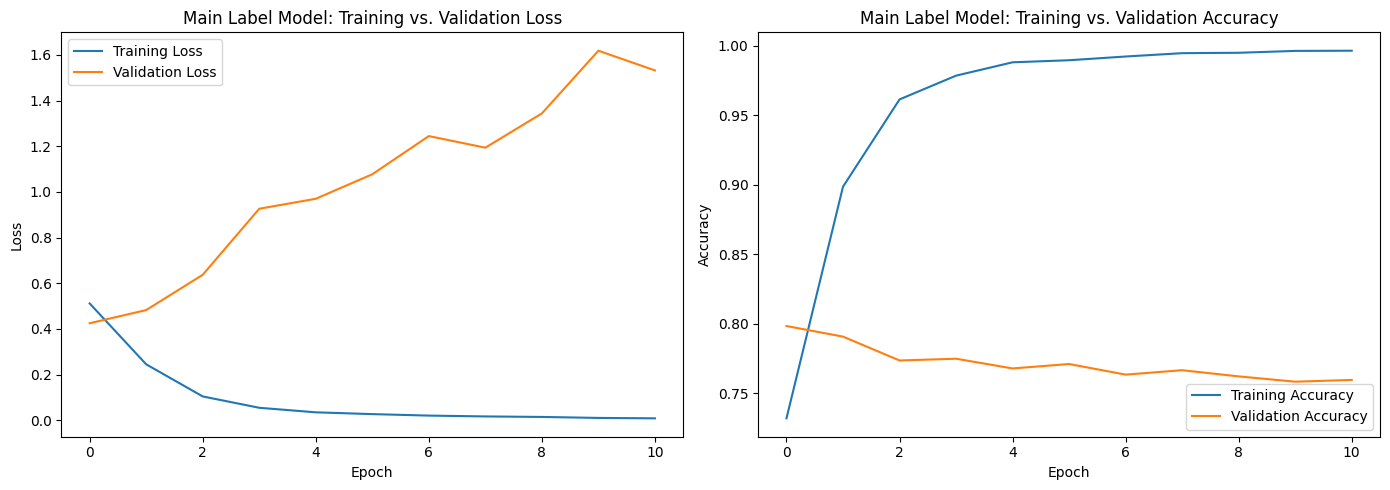

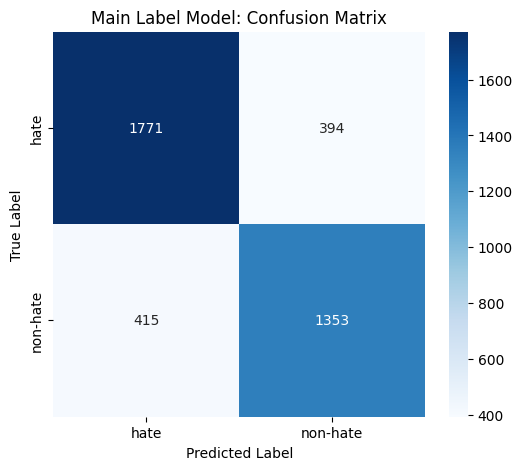


--- Non-Hate Sub-Label Model Plots ---


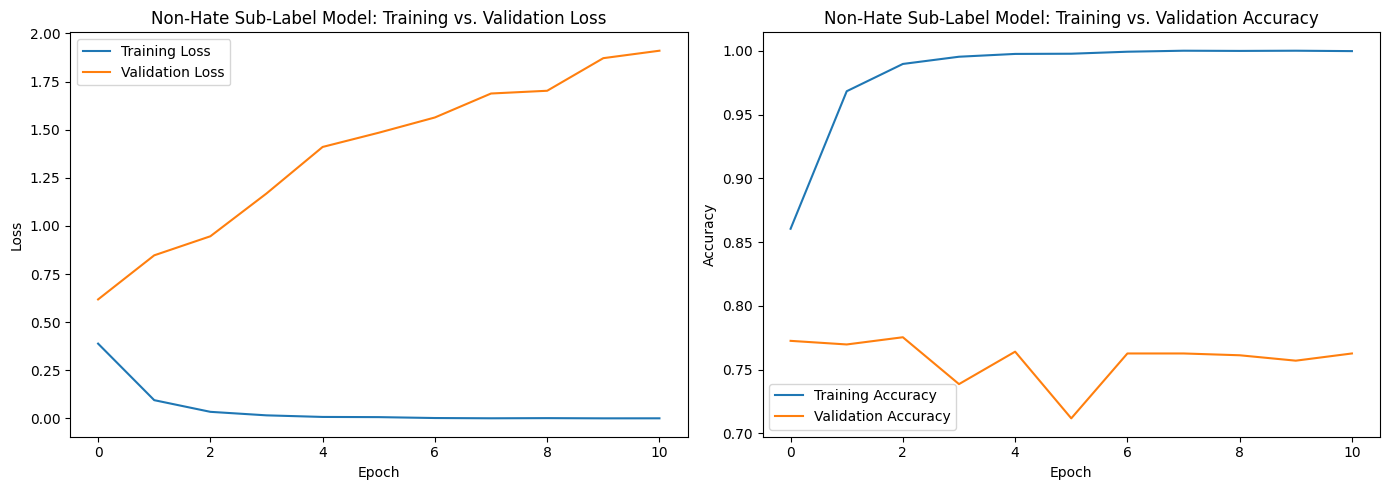

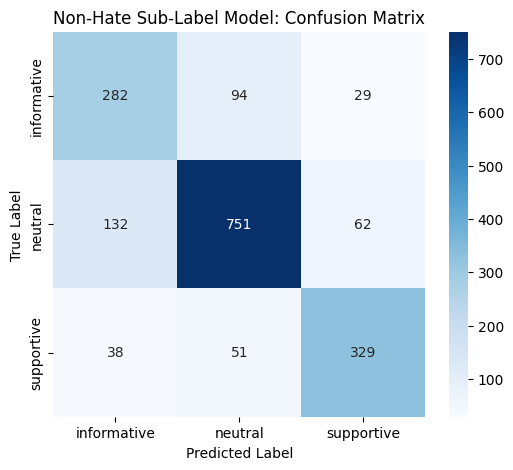


--- Hate Sub-Label Model Plots ---


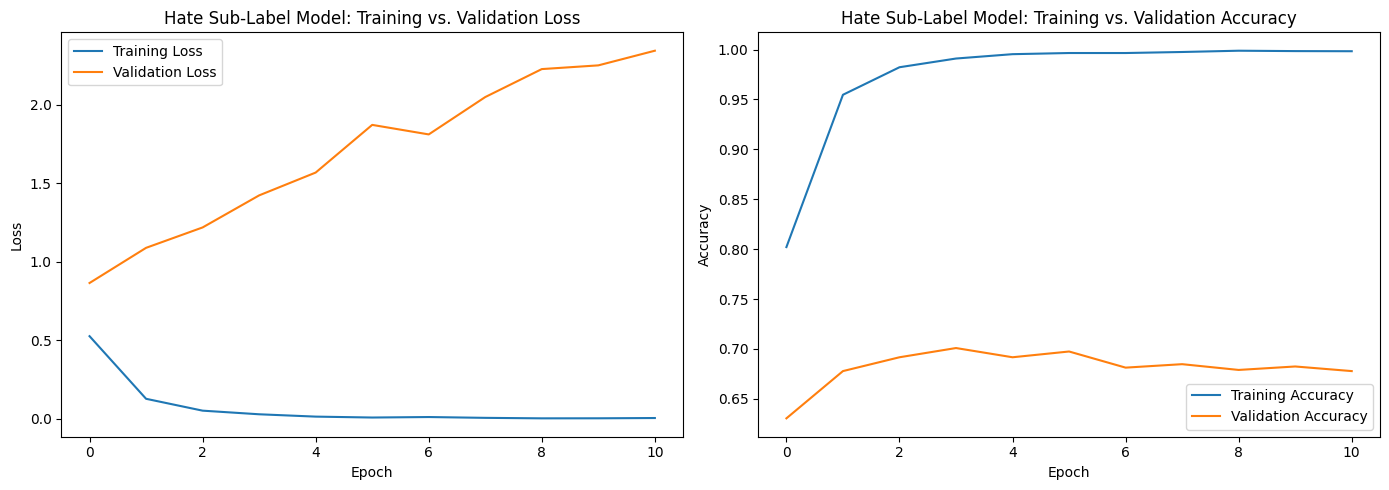

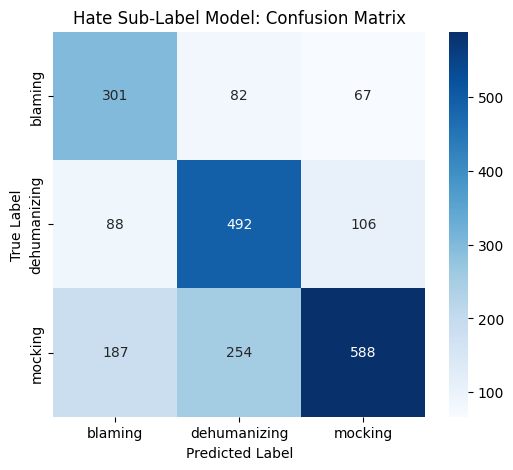

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

# Create a directory for saving plots if it doesn't exist
output_dir = "model_plots"
os.makedirs(output_dir, exist_ok=True)

# --- Main Label Model Plots ---

# Learning Curves for Main Label Model
plt.figure(figsize=(14, 5))

# Plot Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Main Label Model: Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Main Label Model: Training vs. Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'main_label_learning_curves.png'))
plt.show()

# Confusion Matrix for Main Label Model
cm_main = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_main, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Main Label Model: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(os.path.join(output_dir, 'main_label_confusion_matrix.png'))
plt.show()

print("\n--- Non-Hate Sub-Label Model Plots ---")

# Learning Curves for Non-Hate Sub-Label Model
plt.figure(figsize=(14, 5))

# Plot Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history_nh.history['loss'], label='Training Loss')
plt.plot(history_nh.history['val_loss'], label='Validation Loss')
plt.title('Non-Hate Sub-Label Model: Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_nh.history['accuracy'], label='Training Accuracy')
plt.plot(history_nh.history['val_accuracy'], label='Validation Accuracy')
plt.title('Non-Hate Sub-Label Model: Training vs. Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'non_hate_sub_label_learning_curves.png'))
plt.show()

# Confusion Matrix for Non-Hate Sub-Label Model
cm_nh = confusion_matrix(y_test_nh, y_pred_nh_weighted)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nh, annot=True, fmt='d', cmap='Blues', xticklabels=le_sub.classes_, yticklabels=le_sub.classes_)
plt.title('Non-Hate Sub-Label Model: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(os.path.join(output_dir, 'non_hate_sub_label_confusion_matrix.png'))
plt.show()

print("\n--- Hate Sub-Label Model Plots ---")

# Learning Curves for Hate Sub-Label Model
plt.figure(figsize=(14, 5))

# Plot Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history_hate.history['loss'], label='Training Loss')
plt.plot(history_hate.history['val_loss'], label='Validation Loss')
plt.title('Hate Sub-Label Model: Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_hate.history['accuracy'], label='Training Accuracy')
plt.plot(history_hate.history['val_accuracy'], label='Validation Accuracy')
plt.title('Hate Sub-Label Model: Training vs. Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'hate_sub_label_learning_curves.png'))
plt.show()

# Confusion Matrix for Hate Sub-Label Model
cm_hate = confusion_matrix(y_test_hate, y_pred_hate_weighted)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_hate, annot=True, fmt='d', cmap='Blues', xticklabels=le_sub_hate.classes_, yticklabels=le_sub_hate.classes_)
plt.title('Hate Sub-Label Model: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(os.path.join(output_dir, 'hate_sub_label_confusion_matrix.png'))
plt.show()

In [ ]:
 embedding_dims_nh = [64, 128, 256]
 lstm_units_nh = [32, 64, 128]
 dropout_rates_nh = [0.3, 0.5, 0.7]
 dense_units_nh = [32, 64, 128]

 print(f"Embedding Dimensions: {embedding_dims_nh}")
 print(f"LSTM Units: {lstm_units_nh}")
 print(f"Dropout Rates: {dropout_rates_nh}")
 print(f"Dense Layer Units: {dense_units_nh}")

Embedding Dimensions: [64, 128, 256]
LSTM Units: [32, 64, 128]
Dropout Rates: [0.3, 0.5, 0.7]
Dense Layer Units: [32, 64, 128]


# Hyperparameter tuning for sub-label

In [ ]:
 import tensorflow as tf
 from tensorflow.keras.models import Sequential
 from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
 from tensorflow.keras.callbacks import EarlyStopping
 import numpy as np

 # Initialize a list to store results for non-hate sub-labels
 results_nh = []

 # Iterate through all hyperparameter combinations
 for embedding_dim in embedding_dims_nh:
     for lstm_unit in lstm_units_nh:
         for dropout_rate in dropout_rates_nh:
             for dense_unit in dense_units_nh:
                 # Build the model
                 model_hp_nh = Sequential([
                     Embedding(input_dim=vocab_size_nh,
                               output_dim=embedding_dim),
                     Bidirectional(LSTM(lstm_unit)),
                     Dropout(dropout_rate),
                     Dense(dense_unit, activation="relu"),
                     Dense(num_classes_nh, activation="softmax") # Output layer for multi-class classification
                 ])
                 # Compile the model
                 model_hp_nh.compile(
                     loss="sparse_categorical_crossentropy",
                     optimizer="adam",
                     metrics=["accuracy"]
                 )
                # Define early stopping callback
                 early_stop_hp_nh = EarlyStopping(
                     monitor="val_loss",
                     patience=5,
                     restore_best_weights=True,
                     verbose=0 # Suppress verbose output for each model
                 )
                 # Train the model
                 history_hp_nh = model_hp_nh.fit(
                     X_train_nh_pad,
                     y_train_nh,
                     epochs=25,
                     batch_size=32,
                     validation_split=0.1,
                     callbacks=[early_stop_hp_nh],
                     class_weight=class_weights_dict_nh,
                     verbose=0 # Suppress verbose output for each model
                 )

                 # Get the best validation loss and accuracy (restored weights)
                 val_loss_history_nh = history_hp_nh.history['val_loss']
                 val_accuracy_history_nh = history_hp_nh.history['val_accuracy']

                 # Find the epoch with the minimum validation loss
                 best_epoch_idx_nh = np.argmin(val_loss_history_nh)
                 best_val_loss_nh = val_loss_history_nh[best_epoch_idx_nh]
                 best_val_accuracy_nh = val_accuracy_history_nh[best_epoch_idx_nh]

                 # Store the results
                 results_nh.append({
                     "embedding_dim": embedding_dim,
                     "lstm_unit": lstm_unit,
                     "dropout_rate": dropout_rate,
                     "dense_unit": dense_unit,
                     "val_accuracy": best_val_accuracy_nh,
                     "val_loss": best_val_loss_nh
                 })

 print("Hyperparameter tuning for non-hate sub-label models completed. Results stored in 'results_nh'.")
 print(f"Total models trained: {len(results_nh)}")

Hyperparameter tuning for non-hate sub-label models completed. Results stored in 'results_nh'.
Total models trained: 81


In [ ]:
 import pandas as pd

 # Convert results_nh list to a DataFrame
 results_nh_df = pd.DataFrame(results_nh)

 # Sort the DataFrame by 'val_accuracy' in descending order
 best_models_nh = results_nh_df.sort_values(by='val_accuracy', ascending=False)

 print("Top 5 best performing models for non-hate sub-labels (sorted by validation accuracy):")
 print(best_models_nh.head())

 # Extract the hyperparameters of the best performing model
 best_hyperparameters_nh = best_models_nh.iloc[0]

 best_embedding_dim_nh = best_hyperparameters_nh['embedding_dim']
 best_lstm_unit_nh = best_hyperparameters_nh['lstm_unit']
 best_dropout_rate_nh = best_hyperparameters_nh['dropout_rate']
 best_dense_unit_nh = best_hyperparameters_nh['dense_unit']

 print(f"\nBest Hyperparameters (Non-Hate Sub-label Model):\nEmbedding Dimension: {best_embedding_dim_nh}\nLSTM Units: {best_lstm_unit_nh}\nDropout Rate: {best_dropout_rate_nh}\nDense Layer Units: {best_dense_unit_nh}")

Top 5 best performing models for non-hate sub-labels (sorted by validation accuracy):
    embedding_dim  lstm_unit  dropout_rate  dense_unit  val_accuracy  val_loss
42            128         64           0.7          32      0.786723  0.577458
39            128         64           0.5          32      0.785311  0.600071
51            128        128           0.7          32      0.783898  0.636915
29            128         32           0.3         128      0.782486  0.597312
54            256         32           0.3          32      0.778249  0.581504

Best Hyperparameters (Non-Hate Sub-label Model):
Embedding Dimension: 128.0
LSTM Units: 64.0
Dropout Rate: 0.7
Dense Layer Units: 32.0


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Build a new Keras Sequential model using the best hyperparameters
best_model_nh = Sequential([
    Embedding(input_dim=vocab_size_nh,
              output_dim=int(best_embedding_dim_nh)),
    Bidirectional(LSTM(int(best_lstm_unit_nh))),
    Dropout(best_dropout_rate_nh),
    Dense(int(best_dense_unit_nh), activation="relu"),
    Dense(num_classes_nh, activation="softmax") # Output layer for multi-class classification
])

# 2. Compile the model
best_model_nh.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Define early stopping callback (monitoring training loss as there's no validation split during this fit)
early_stop_final_nh = EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True
)

print("Training the best non-hate sub-label model on the full training dataset...")
# 3. Train this model on the entire X_train_nh_pad and y_train_nh dataset
history_final_nh = best_model_nh.fit(
    X_train_nh_pad,
    y_train_nh,
    epochs=25, # You can adjust this based on observation
    batch_size=32,
    callbacks=[early_stop_final_nh],
    class_weight=class_weights_dict_nh
)

print("Non-hate sub-label model training complete. Now evaluating on the test set.")

# 4. Predict the probabilities for the X_test_nh_pad data
y_pred_prob_final_nh = best_model_nh.predict(X_test_nh_pad)

# 5. Convert the predicted probabilities to class labels
y_pred_final_nh = np.argmax(y_pred_prob_final_nh, axis=1)

# 6. Calculate and print the accuracy score
accuracy_final_nh = accuracy_score(y_test_nh, y_pred_final_nh)
print("\nAccuracy (Best Non-Hate Sub-labels Model):", accuracy_final_nh)

# 7. Print the classification report
print("\nClassification Report (Best Non-Hate Sub-labels Model):")
print(classification_report(y_test_nh, y_pred_final_nh, target_names=le_sub.classes_))

# 8. Print the confusion matrix
print("\nConfusion Matrix (Best Non-Hate Sub-labels Model):")
print(confusion_matrix(y_test_nh, y_pred_final_nh))

Training the best non-hate sub-label model on the full training dataset...
Epoch 1/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5468 - loss: 1.0178
Epoch 2/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8599 - loss: 0.4077
Epoch 3/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9596 - loss: 0.1358
Epoch 4/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9824 - loss: 0.0490
Epoch 5/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9915 - loss: 0.0272
Epoch 6/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9932 - loss: 0.0210
Epoch 7/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9965 - loss: 0.0117
Epoch 8/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9972 - loss: 0.0121
Epoch 9/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9986 - loss: 0.0058
Epoch 10/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9973 - loss: 0.0060
Epoch 11/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step 

In [ ]:
get_ipython().system('pip install joblib')

In [ ]:
import joblib
import tensorflow as tf

# Save the best main label classification Keras model
tf.keras.models.save_model(best_model_main, 'main_label_model.h5')
print("Saved 'main_label_model.h5'")

# Save the LabelEncoder for main labels
joblib.dump(le, 'main_label_encoder.pkl')
print("Saved 'main_label_encoder.pkl'")

# Save the Tokenizer for main labels
joblib.dump(tokenizer, 'main_label_tokenizer.pkl')
print("Saved 'main_label_tokenizer.pkl'")

# Save the max_length for main labels
joblib.dump(max_length, 'main_label_max_length.pkl')
print("Saved 'main_label_max_length.pkl'")

Saved 'main_label_model.h5'
Saved 'main_label_encoder.pkl'
Saved 'main_label_tokenizer.pkl'
Saved 'main_label_max_length.pkl'


In [ ]:
import joblib
import tensorflow as tf

# Save the best non-hate sub-label classification Keras model
tf.keras.models.save_model(best_model_nh, 'non_hate_sub_label_model.h5')
print("Saved 'non_hate_sub_label_model.h5'")

# Save the LabelEncoder for non-hate sub-labels
joblib.dump(le_sub, 'non_hate_sub_label_encoder.pkl')
print("Saved 'non_hate_sub_label_encoder.pkl'")

# Save the Tokenizer for non-hate sub-labels
joblib.dump(tokenizer_nh, 'non_hate_sub_label_tokenizer.pkl')
print("Saved 'non_hate_sub_label_tokenizer.pkl'")

# Save the max_length for non-hate sub-labels
joblib.dump(max_length_nh, 'non_hate_sub_label_max_length.pkl')
print("Saved 'non_hate_sub_label_max_length.pkl'")

Saved 'non_hate_sub_label_model.h5'
Saved 'non_hate_sub_label_encoder.pkl'
Saved 'non_hate_sub_label_tokenizer.pkl'
Saved 'non_hate_sub_label_max_length.pkl'


In [ ]:
import joblib
import tensorflow as tf

# Save the best hate sub-label classification Keras model
tf.keras.models.save_model(best_model_hate, 'hate_sub_label_model.h5')
print("Saved 'hate_sub_label_model.h5'")

# Save the LabelEncoder for hate sub-labels
joblib.dump(le_sub_hate, 'hate_sub_label_encoder.pkl')
print("Saved 'hate_sub_label_encoder.pkl'")

# Save the Tokenizer for hate sub-labels
joblib.dump(tokenizer_hate, 'hate_sub_label_tokenizer.pkl')
print("Saved 'hate_sub_label_tokenizer.pkl'")

# Save the max_length for hate sub-labels
joblib.dump(max_length_hate, 'hate_sub_label_max_length.pkl')
print("Saved 'hate_sub_label_max_length.pkl'")

Saved 'hate_sub_label_model.h5'
Saved 'hate_sub_label_encoder.pkl'
Saved 'hate_sub_label_tokenizer.pkl'
Saved 'hate_sub_label_max_length.pkl'


In [ ]:
import joblib

# Save the nepali_stopwords set
joblib.dump(nepali_stopwords, 'nepali_stopwords.pkl')
print("Saved 'nepali_stopwords.pkl'")

Saved 'nepali_stopwords.pkl'


In [ ]:
import re
import unicodedata
import pandas as pd

def preprocess_raw_text_for_wordcloud(text):
    if pd.isna(text):
        return ""
    text = str(text)

    # Normalize Unicode
    text = unicodedata.normalize("NFC", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove emojis
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub('', text)

    # Remove all punctuation except spaces (specifically targeting common English and some Devanagari punctuation)
    # This regex keeps Devanagari characters, English letters, numbers, and spaces.
    # It effectively removes other symbols like . , ! ? etc. that might be attached to words.
    text = re.sub(r'[^\u0900-\u097Fa-zA-Z0-9\s]', '', text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply this new function to the original 'text' column to get cleaned raw text for word cloud
df['raw_cleaned_for_wordcloud'] = df['text'].apply(preprocess_raw_text_for_wordcloud)

print(df[['text', 'raw_cleaned_for_wordcloud']].head())

                                                text  \
0  आजसम्म तिमिहरुले एउटा गतिलो नेपालि फ्लिम बनायन...   
1  काठमाडौँ उपत्यका खानेपानी लिमिटेड (केयुकेएल) म...   
3                                     थुग वीएस गोट 🤣   
5             तिमीले मनलाग्दी बोलेर जनता नझुकाई देउ।   
7                        नेपाली बाबु सारै ह्यान्डसम।   

                           raw_cleaned_for_wordcloud  
0  आजसम्म तिमिहरुले एउटा गतिलो नेपालि फ्लिम बनायन...  
1  काठमाडौँ उपत्यका खानेपानी लिमिटेड केयुकेएल महा...  
3                                       थुग वीएस गोट  
5             तिमीले मनलाग्दी बोलेर जनता नझुकाई देउ।  
7                        नेपाली बाबु सारै ह्यान्डसम।  


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import os

# Combine all processed 'raw_cleaned_for_wordcloud' entries into a single string
all_words_final_string = ' '.join(df['raw_cleaned_for_wordcloud'])

# Explicitly tokenize the cleaned string by whitespace
explicit_words = all_words_final_string.split()

# Count the frequency of each word
word_frequencies = Counter(explicit_words)

# Define a local directory for fonts
font_dir = './custom_fonts'
os.makedirs(font_dir, exist_ok=True)
font_filename = 'NotoSansDevanagari-Regular.ttf' # Still preferred if directly available
font_path = os.path.join(font_dir, font_filename)

# Try to install fonts-indic for a robust Devanagari font source
print("Installing fonts-indic...")
get_ipython().system('apt-get update -qq > /dev/null')
get_ipython().system('apt-get install -y fonts-indic > /dev/null')
print("fonts-indic installed.")

# Attempt to find a Devanagari font after installation
# Common paths for Noto Sans Devanagari within fonts-indic or general system fonts
possible_font_paths = [
    '/usr/share/fonts/truetype/noto/NotoSansDevanagari-Regular.ttf',
    '/usr/share/fonts/truetype/lohit-devanagari/Lohit-Devanagari.ttf', # An alternative
    font_path # Fallback to the original download path if system font not found
]

found_font_path = None
for path in possible_font_paths:
    if os.path.exists(path):
        found_font_path = path
        print(f"Using Devanagari font: {found_font_path}")
        break

if not found_font_path:
    print("Could not find a suitable Devanagari font even after installing fonts-indic. Attempting direct download fallback.")
    # Fallback to direct wget if system fonts are not found or accessible
    if os.path.exists(font_path):
        print(f"Removing existing {font_filename} to ensure fresh direct download.")
        os.remove(font_path)
    print(f"Downloading {font_filename} from GitHub...")
    get_ipython().system(f'wget -q "https://raw.githubusercontent.com/googlefonts/noto-fonts/main/hinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf" -O {font_path}')
    if os.path.exists(font_path):
        found_font_path = font_path
        print(f"{font_filename} downloaded successfully to {found_font_path}")
    else:
        print(f"Error: Failed to direct download {font_filename}.")


# Generate word cloud using the word frequencies directly
if found_font_path and os.path.exists(found_font_path):
    wordcloud_final = WordCloud(
        width=800,
        height=400,
        background_color='white',
        font_path=found_font_path,
        collocations=False
    ).generate_from_frequencies(word_frequencies);

    # Display the generated image:
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud_final, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most Repeated Words in Original Raw Text (Cleaned & Explicitly Tokenized)')
    plt.show()
else:
    print("Word cloud cannot be generated due to missing or corrupted Devanagari font. Please ensure a valid font is available.")

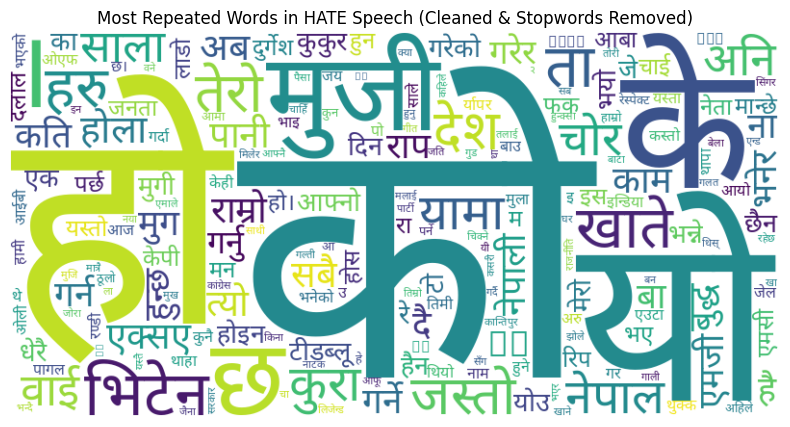

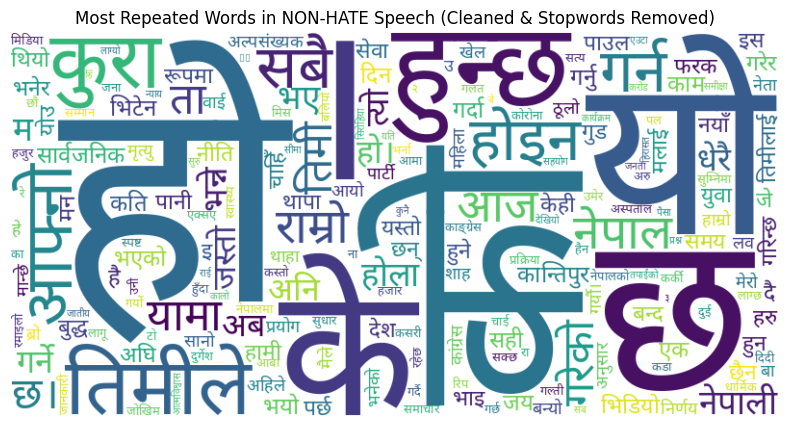

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import os

# Re-create hate_df and non_hate_df after 'raw_cleaned_for_wordcloud' has been added to df
hate_df = df[df['main_label'] == 'hate'].copy()
non_hate_df = df[df['main_label'] == 'non-hate'].copy()

# --- Word Cloud for HATE main_label ---

# Combine all 'raw_cleaned_for_wordcloud' entries from hate_df into a single string
hate_text = ' '.join(hate_df['raw_cleaned_for_wordcloud'])

# Filter out stopwords from the hate text
filtered_hate_words = [word for word in hate_text.split() if word not in nepali_stopwords]
filtered_hate_text = ' '.join(filtered_hate_words)

# Use the previously downloaded font path
font_dir = './custom_fonts'
font_filename = 'NotoSansDevanagari-Regular.ttf'
font_path = os.path.join(font_dir, font_filename)

if os.path.exists(font_path):
    # Count frequencies for hate words
    hate_word_frequencies = Counter(filtered_hate_words)

    # Generate word cloud for hate words
    wordcloud_hate = WordCloud(
        width=800,
        height=400,
        background_color='white',
        font_path=font_path,
        collocations=False
    ).generate_from_frequencies(hate_word_frequencies);

    # Display the generated image:
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud_hate, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most Repeated Words in HATE Speech (Cleaned & Stopwords Removed)')
    plt.show()
else:
    print(f"Word cloud for HATE speech cannot be generated. Font not found at {font_path}")


# --- Word Cloud for NON-HATE main_label ---

# Combine all 'raw_cleaned_for_wordcloud' entries from non_hate_df into a single string
non_hate_text = ' '.join(non_hate_df['raw_cleaned_for_wordcloud'])

# Filter out stopwords from the non-hate text
filtered_non_hate_words = [word for word in non_hate_text.split() if word not in nepali_stopwords]
filtered_non_hate_text = ' '.join(filtered_non_hate_words)

if os.path.exists(font_path):
    # Count frequencies for non-hate words
    non_hate_word_frequencies = Counter(filtered_non_hate_words)

    # Generate word cloud for non-hate words
    wordcloud_non_hate = WordCloud(
        width=800,
        height=400,
        background_color='white',
        font_path=font_path,
        collocations=False
    ).generate_from_frequencies(non_hate_word_frequencies);

    # Display the generated image:
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud_non_hate, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most Repeated Words in NON-HATE Speech (Cleaned & Stopwords Removed)')
    plt.show()
else:
    print(f"Word cloud for NON-HATE speech cannot be generated. Font not found at {font_path}")

## Hyperparameter Tuning (Hate Sub-label Model)



In [ ]:
embedding_dims = [32, 64, 128]
lstm_units = [16, 32, 64]
dropout_rates = [0.3, 0.5, 0.7]
dense_units = [16, 32, 64]

print(f"Embedding Dimensions: {embedding_dims}")
print(f"LSTM Units: {lstm_units}")
print(f"Dropout Rates: {dropout_rates}")
print(f"Dense Layer Units: {dense_units}")

Embedding Dimensions: [32, 64, 128]
LSTM Units: [16, 32, 64]
Dropout Rates: [0.3, 0.5, 0.7]
Dense Layer Units: [16, 32, 64]


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Initialize a list to store results
results_hate = []

# Iterate through all hyperparameter combinations
for embedding_dim in embedding_dims:
    for lstm_unit in lstm_units:
        for dropout_rate in dropout_rates:
            for dense_unit in dense_units:
                # Build the model
                model_hp = Sequential([
                    Embedding(input_dim=vocab_size_hate,
                              output_dim=embedding_dim),
                    Bidirectional(LSTM(lstm_unit)),
                    Dropout(dropout_rate),
                    Dense(dense_unit, activation="relu"),
                    Dense(num_classes_hate, activation="softmax")
                ])

                # Compile the model
                model_hp.compile(
                    loss="sparse_categorical_crossentropy",
                    optimizer="adam",
                    metrics=["accuracy"]
                )

                # Define early stopping callback
                early_stop_hp = EarlyStopping(
                    monitor="val_loss",
                    patience=5,
                    restore_best_weights=True,
                    verbose=0 # Suppress verbose output for each model
                )

                # Train the model
                history_hp = model_hp.fit(
                    X_train_hate_pad,
                    y_train_hate,
                    epochs=25,
                    batch_size=32,
                    validation_split=0.1,
                    callbacks=[early_stop_hp],
                    class_weight=class_weights_dict_hate,
                    verbose=0 # Suppress verbose output for each model
                )

                # Get the best validation loss and accuracy (restored weights)
                val_loss_history = history_hp.history['val_loss']
                val_accuracy_history = history_hp.history['val_accuracy']

                # Find the epoch with the minimum validation loss
                best_epoch_idx = np.argmin(val_loss_history)
                best_val_loss = val_loss_history[best_epoch_idx]
                best_val_accuracy = val_accuracy_history[best_epoch_idx]

                # Store the results
                results_hate.append({
                    "embedding_dim": embedding_dim,
                    "lstm_unit": lstm_unit,
                    "dropout_rate": dropout_rate,
                    "dense_unit": dense_unit,
                    "val_accuracy": best_val_accuracy,
                    "val_loss": best_val_loss
                })

print("Hyperparameter tuning completed. Results stored in 'results_hate'.")
print(f"Total models trained: {len(results_hate)}")

Hyperparameter tuning completed. Results stored in 'results_hate'.
Total models trained: 81


In [ ]:
import pandas as pd

# Convert results_hate list to a DataFrame
results_hate_df = pd.DataFrame(results_hate)

# Sort the DataFrame by 'val_accuracy' in descending order
best_models_hate = results_hate_df.sort_values(by='val_accuracy', ascending=False)

print("Top 5 best performing models for hate sub-labels (sorted by validation accuracy):")
print(best_models_hate.head())

# Extract the hyperparameters of the best performing model
best_hyperparameters = best_models_hate.iloc[0]

best_embedding_dim = best_hyperparameters['embedding_dim']
best_lstm_unit = best_hyperparameters['lstm_unit']
best_dropout_rate = best_hyperparameters['dropout_rate']
best_dense_unit = best_hyperparameters['dense_unit']

print(f"\nBest Hyperparameters:\nEmbedding Dimension: {best_embedding_dim}\nLSTM Units: {best_lstm_unit}\nDropout Rate: {best_dropout_rate}\nDense Layer Units: {best_dense_unit}")

Top 5 best performing models for hate sub-labels (sorted by validation accuracy):
    embedding_dim  lstm_unit  dropout_rate  dense_unit  val_accuracy  val_loss
59            128         16           0.5          64      0.714781  0.746396
29             64         16           0.3          64      0.702079  0.747174
71            128         32           0.7          64      0.700924  0.758395
64            128         32           0.3          32      0.693995  0.781578
54            128         16           0.3          16      0.692841  0.758896

Best Hyperparameters:
Embedding Dimension: 128.0
LSTM Units: 16.0
Dropout Rate: 0.5
Dense Layer Units: 64.0


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Build a new Keras Sequential model using the best hyperparameters
best_model_hate = Sequential([
    Embedding(input_dim=vocab_size_hate,
              output_dim=int(best_embedding_dim)),
    Bidirectional(LSTM(int(best_lstm_unit))),
    Dropout(best_dropout_rate),
    Dense(int(best_dense_unit), activation="relu"),
    Dense(num_classes_hate, activation="softmax") # Output layer for multi-class classification
])

# 2. Compile the model
best_model_hate.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Define early stopping callback (monitoring training loss as there's no validation split during this fit)
early_stop_final_hate = EarlyStopping(
    monitor="loss", # Monitor training loss as there's no validation split
    patience=5,
    restore_best_weights=True
)

print("Training the best model on the full training dataset...")
# 3. Train this model on the entire X_train_hate_pad and y_train_hate dataset
history_final_hate = best_model_hate.fit(
    X_train_hate_pad,
    y_train_hate,
    epochs=25, # You can adjust this based on observation
    batch_size=32,
    callbacks=[early_stop_final_hate],
    class_weight=class_weights_dict_hate
)

print("Model training complete. Now evaluating on the test set.")

# 4. Predict the probabilities for the X_test_hate_pad data
y_pred_prob_final_hate = best_model_hate.predict(X_test_hate_pad)

# 5. Convert the predicted probabilities to class labels
y_pred_final_hate = np.argmax(y_pred_prob_final_hate, axis=1)

# 6. Calculate and print the accuracy score
accuracy_final_hate = accuracy_score(y_test_hate, y_pred_final_hate)
print("\nAccuracy (Best Hate Sub-labels Model):", accuracy_final_hate)

# 7. Print the classification report
print("\nClassification Report (Best Hate Sub-labels Model):")
print(classification_report(y_test_hate, y_pred_final_hate, target_names=le_sub_hate.classes_))

# 8. Print the confusion matrix
print("\nConfusion Matrix (Best Hate Sub-labels Model):")
print(confusion_matrix(y_test_hate, y_pred_final_hate))

Training the best model on the full training dataset...
Epoch 1/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3781 - loss: 1.0654
Epoch 2/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7894 - loss: 0.5608
Epoch 3/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9448 - loss: 0.1886
Epoch 4/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9781 - loss: 0.0716
Epoch 5/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9911 - loss: 0.0326
Epoch 6/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9910 - loss: 0.0256
Epoch 7/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9937 - loss: 0.0233
Epoch 8/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9931 - loss: 0.0225
Epoch 9/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9928 - loss: 0.0217
Epoch 10/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9928 - loss: 0.0175
Epoch 11/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9955 

In [ ]:
import joblib
import tensorflow as tf

# Save the best hate sub-label classification Keras model
tf.keras.models.save_model(best_model_hate, 'hate_sub_label_model.h5')
print("Saved 'hate_sub_label_model.h5'")

# Save the LabelEncoder for hate sub-labels
joblib.dump(le_sub_hate, 'hate_sub_label_encoder.pkl')
print("Saved 'hate_sub_label_encoder.pkl'")

# Save the Tokenizer for hate sub-labels
joblib.dump(tokenizer_hate, 'hate_sub_label_tokenizer.pkl')
print("Saved 'hate_sub_label_tokenizer.pkl'")

# Save the max_length for hate sub-labels
joblib.dump(max_length_hate, 'hate_sub_label_max_length.pkl')
print("Saved 'hate_sub_label_max_length.pkl'")

Saved 'hate_sub_label_model.h5'
Saved 'hate_sub_label_encoder.pkl'
Saved 'hate_sub_label_tokenizer.pkl'
Saved 'hate_sub_label_max_length.pkl'


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Build a new Keras Sequential model using the best hyperparameters
best_model_main = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=int(best_embedding_dim_main)),
    Bidirectional(LSTM(int(best_lstm_unit_main))),
    Dropout(best_dropout_rate_main),
    Dense(int(best_dense_unit_main), activation="relu"),
    Dense(1, activation="sigmoid") # Output layer for binary classification
])

# 2. Compile the model
best_model_main.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Define early stopping callback (monitoring training loss as there's no validation split during this fit)
early_stop_final_main = EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True
)

print("Training the best main label model on the full training dataset...")
# 3. Train this model on the entire X_train_pad and y_train dataset
history_final_main = best_model_main.fit(
    X_train_pad,
    y_train,
    epochs=25, # You can adjust this based on observation
    batch_size=32,
    callbacks=[early_stop_final_main]
)

print("Main label model training complete. Now evaluating on the test set.")

# 4. Predict the probabilities for the X_test_pad data
y_pred_prob_final_main = best_model_main.predict(X_test_pad)

# 5. Convert the predicted probabilities to class labels (0 or 1)
y_pred_final_main = (y_pred_prob_final_main > 0.5).astype("int32")

# 6. Calculate and print the accuracy score
accuracy_final_main = accuracy_score(y_test, y_pred_final_main)
print("\nAccuracy (Best Main Label Model):", accuracy_final_main)

# 7. Print the classification report
print("\nClassification Report (Best Main Label Model):")
print(classification_report(y_test, y_pred_final_main, target_names=le.classes_))

# 8. Print the confusion matrix
print("\nConfusion Matrix (Best Main Label Model):")
print(confusion_matrix(y_test, y_pred_final_main))

Training the best main label model on the full training dataset...
Epoch 1/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6757 - loss: 0.5739
Epoch 2/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9095 - loss: 0.2313
Epoch 3/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9656 - loss: 0.0923
Epoch 4/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9815 - loss: 0.0484
Epoch 5/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9866 - loss: 0.0352
Epoch 6/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9903 - loss: 0.0242
Epoch 7/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9947 - loss: 0.0143
Epoch 8/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9933 - loss: 0.0155
Epoch 9/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9946 - loss: 0.0161
Epoch 10/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9959 - loss: 0.0100
Epoch 11/25
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accu

In [ ]:
embedding_dims_main = [64, 128, 256]
lstm_units_main = [32, 64, 128]
dropout_rates_main = [0.3, 0.5, 0.7]
dense_units_main = [32, 64, 128]

print(f"Embedding Dimensions: {embedding_dims_main}")
print(f"LSTM Units: {lstm_units_main}")
print(f"Dropout Rates: {dropout_rates_main}")
print(f"Dense Layer Units: {dense_units_main}")

Embedding Dimensions: [64, 128, 256]
LSTM Units: [32, 64, 128]
Dropout Rates: [0.3, 0.5, 0.7]
Dense Layer Units: [32, 64, 128]


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Initialize a list to store results
results_main = []

# Iterate through all hyperparameter combinations
for embedding_dim in embedding_dims_main:
    for lstm_unit in lstm_units_main:
        for dropout_rate in dropout_rates_main:
            for dense_unit in dense_units_main:
                # Build the model
                model_hp = Sequential([
                    Embedding(input_dim=vocab_size,
                              output_dim=embedding_dim),
                    Bidirectional(LSTM(lstm_unit)),
                    Dropout(dropout_rate),
                    Dense(dense_unit, activation="relu"),
                    Dense(1, activation="sigmoid") # Binary classification for main_label
                ])

                # Compile the model
                model_hp.compile(
                    loss="binary_crossentropy",
                    optimizer="adam",
                    metrics=["accuracy"]
                )

                # Define early stopping callback
                early_stop_hp = EarlyStopping(
                    monitor="val_loss",
                    patience=5,
                    restore_best_weights=True,
                    verbose=0 # Suppress verbose output for each model
                )

                # Train the model
                history_hp = model_hp.fit(
                    X_train_pad,
                    y_train,
                    epochs=25,
                    batch_size=32,
                    validation_split=0.1,
                    callbacks=[early_stop_hp],
                    verbose=0 # Suppress verbose output for each model
                )

                # Get the best validation loss and accuracy (restored weights)
                val_loss_history = history_hp.history['val_loss']
                val_accuracy_history = history_hp.history['val_accuracy']

                # Find the epoch with the minimum validation loss
                best_epoch_idx = np.argmin(val_loss_history)
                best_val_loss = val_loss_history[best_epoch_idx]
                best_val_accuracy = val_accuracy_history[best_epoch_idx]

                # Store the results
                results_main.append({
                    "embedding_dim": embedding_dim,
                    "lstm_unit": lstm_unit,
                    "dropout_rate": dropout_rate,
                    "dense_unit": dense_unit,
                    "val_accuracy": best_val_accuracy,
                    "val_loss": best_val_loss
                })

print("Hyperparameter tuning for main label models completed. Results stored in 'results_main'.")
print(f"Total models trained: {len(results_main)}")

KeyboardInterrupt: 

In [ ]:
import pandas as pd

# Convert results_main list to a DataFrame
results_main_df = pd.DataFrame(results_main)

# Sort the DataFrame by 'val_accuracy' in descending order
best_models_main = results_main_df.sort_values(by='val_accuracy', ascending=False)

print("Top 5 best performing models for main labels (sorted by validation accuracy):")
print(best_models_main.head())

# Extract the hyperparameters of the best performing model
best_hyperparameters_main = best_models_main.iloc[0]

best_embedding_dim_main = best_hyperparameters_main['embedding_dim']
best_lstm_unit_main = best_hyperparameters_main['lstm_unit']
best_dropout_rate_main = best_hyperparameters_main['dropout_rate']
best_dense_unit_main = best_hyperparameters_main['dense_unit']

print(f"\nBest Hyperparameters (Main Label Model):\nEmbedding Dimension: {best_embedding_dim_main}\nLSTM Units: {best_lstm_unit_main}\nDropout Rate: {best_dropout_rate_main}\nDense Layer Units: {best_dense_unit_main}")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Build a new Keras Sequential model using the best hyperparameters
best_model_main = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=int(best_embedding_dim_main)),
    Bidirectional(LSTM(int(best_lstm_unit_main))),
    Dropout(best_dropout_rate_main),
    Dense(int(best_dense_unit_main), activation="relu"),
    Dense(1, activation="sigmoid") # Output layer for binary classification
])

# 2. Compile the model
best_model_main.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Define early stopping callback (monitoring training loss as there's no validation split during this fit)
early_stop_final_main = EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True
)

print("Training the best main label model on the full training dataset...")
# 3. Train this model on the entire X_train_pad and y_train dataset
history_final_main = best_model_main.fit(
    X_train_pad,
    y_train,
    epochs=25, # You can adjust this based on observation
    batch_size=32,
    callbacks=[early_stop_final_main]
)

print("Main label model training complete. Now evaluating on the test set.")

# 4. Predict the probabilities for the X_test_pad data
y_pred_prob_final_main = best_model_main.predict(X_test_pad)

# 5. Convert the predicted probabilities to class labels (0 or 1)
y_pred_final_main = (y_pred_prob_final_main > 0.5).astype("int32")

# 6. Calculate and print the accuracy score
accuracy_final_main = accuracy_score(y_test, y_pred_final_main)
print("\nAccuracy (Best Main Label Model):", accuracy_final_main)

# 7. Print the classification report
print("\nClassification Report (Best Main Label Model):")
print(classification_report(y_test, y_pred_final_main, target_names=le.classes_))

# 8. Print the confusion matrix
print("\nConfusion Matrix (Best Main Label Model):")
print(confusion_matrix(y_test, y_pred_final_main))

In [ ]:
import joblib
import tensorflow as tf

# Save the best main label classification Keras model
tf.keras.models.save_model(best_model_main, 'main_label_model.h5')
print("Saved 'main_label_model.h5'")

# Save the LabelEncoder for main labels
joblib.dump(le, 'main_label_encoder.pkl')
print("Saved 'main_label_encoder.pkl'")

# Save the Tokenizer for main labels
joblib.dump(tokenizer, 'main_label_tokenizer.pkl')
print("Saved 'main_label_tokenizer.pkl'")

# Save the max_length for main labels
joblib.dump(max_length, 'main_label_max_length.pkl')
print("Saved 'main_label_max_length.pkl'")

In [ ]:
import joblib
import tensorflow as tf

# Save the best main label classification Keras model
tf.keras.models.save_model(best_model_main, 'main_label_model.h5')
print("Saved 'main_label_model.h5'")

# Save the LabelEncoder for main labels
joblib.dump(le, 'main_label_encoder.pkl')
print("Saved 'main_label_encoder.pkl'")

# Save the Tokenizer for main labels
joblib.dump(tokenizer, 'main_label_tokenizer.pkl')
print("Saved 'main_label_tokenizer.pkl'")

# Save the max_length for main labels
joblib.dump(max_length, 'main_label_max_length.pkl')
print("Saved 'main_label_max_length.pkl'")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Build a new Keras Sequential model using the best hyperparameters
best_model_main = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=int(best_embedding_dim_main)),
    Bidirectional(LSTM(int(best_lstm_unit_main))),
    Dropout(best_dropout_rate_main),
    Dense(int(best_dense_unit_main), activation="relu"),
    Dense(1, activation="sigmoid") # Output layer for binary classification
])

# 2. Compile the model
best_model_main.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Define early stopping callback (monitoring training loss as there's no validation split during this fit)
early_stop_final_main = EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True
)

print("Training the best main label model on the full training dataset...")
# 3. Train this model on the entire X_train_pad and y_train dataset
history_final_main = best_model_main.fit(
    X_train_pad,
    y_train,
    epochs=25, # You can adjust this based on observation
    batch_size=32,
    callbacks=[early_stop_final_main]
)

print("Main label model training complete. Now evaluating on the test set.")

# 4. Predict the probabilities for the X_test_pad data
y_pred_prob_final_main = best_model_main.predict(X_test_pad)

# 5. Convert the predicted probabilities to class labels (0 or 1)
y_pred_final_main = (y_pred_prob_final_main > 0.5).astype("int32")

# 6. Calculate and print the accuracy score
accuracy_final_main = accuracy_score(y_test, y_pred_final_main)
print("\nAccuracy (Best Main Label Model):", accuracy_final_main)

# 7. Print the classification report
print("\nClassification Report (Best Main Label Model):")
print(classification_report(y_test, y_pred_final_main, target_names=le.classes_))

# 8. Print the confusion matrix
print("\nConfusion Matrix (Best Main Label Model):")
print(confusion_matrix(y_test, y_pred_final_main))